In [1]:
# TODO Currently accesses .pos files from local directory. Must change to download from Zenodo when available

# Zachary Katz
# zachary_katz@mines.edu

"""
Make and save the catalog of Whillans Stick Slip Events from .pos files, 
available from XXX at DOI. Keep the .pos files in the same folder
structure they were downloaded as, and set the top level directory as the
variable dir below. Make 

v1.0 01 November 2024
    Clean catalog creation using Catalog.py
    Outputs Events, EventStartTimes, and NoData folders
v2.0 08 March 2024
    Paper Version
"""


# Imports
import os
import logging
from concurrent.futures import ThreadPoolExecutor

import sys

sys.path.append("..")

import src.Catalog.Catalog as Catalog

%reload_ext autoreload
%autoreload 2

################################################################################
########################## User Defined Variables ##############################
# fmt: off

# Stations, Years, Data Path
dir = "/mnt/c/Users/ZacharyKatz/Desktop/0304_Processed"
stas = ["CIR1", "RAB1", "RBC1","W1B0","W1C","W1D","W1E","W2A","W2B","W2C","W2D","W2F","W3A","W3B","W3C","W3D","W3G","W4A","W4B","W4C","W5A","W5B","W5C",
            "A010","AFLT","B010","B090","B140","B190","B320","BFLT","BRWN","C010","C060","CIR1","D010","D090","D130","DFLT","E010","EFLT","G2AA","RCD1","SDM1",


        ]
#stas = ["W5A", "W5B"] # For testing purposes
year_arr = [["2004"]]
# Detection parameters
max_gap_len = 120 # Maximum gap length to interpolate [seconds]
window = 150 # Window size for least-squares averaging [minutes]
slide = 5 # Slide size for least-squares averaging [minutes]
cull_time = 30 # Remove catalog events lasting less than this time [minutes]
cull_dist = 0.1 # Remove catalog events with less than this distance [meters]
plot_bool = False # Flag to plot catalog
min_stas = 2 # Minimum number of active stations needed for an event
hr_off = 0 # Offset for hours on either side of threshold to save [hours]d

# Log Level
# Currently implemented: ERROR, WARNING, INFO, DEBUG
# Each level also includes all levels above it.
loglevel = "INFO" 

# fmt: on
########################## User Defined Variables ##############################
################################################################################


# Helper functions
def set_log_level(loglevel: str) -> None:
    """Set logging level for the run

    Parameters
    ----------
    loglevel : str
        Logging level
    """
    FORMAT = "%(asctime)s %(name)s %(levelname)s: %(message)s"
    DATEFMT = "%Y-%m-%d %H:%M:%S"
    if loglevel == "ERROR":
        logging.basicConfig(
            format=FORMAT, datefmt=DATEFMT, level=logging.ERROR, force=True
        )
    elif loglevel == "WARNING":
        logging.basicConfig(
            format=FORMAT, datefmt=DATEFMT, level=logging.WARNING, force=True
        )
    elif loglevel == "INFO":
        logging.basicConfig(
            format=FORMAT, datefmt=DATEFMT, level=logging.INFO, force=True
        )
    elif loglevel == "DEBUG":
        logging.basicConfig(
            format=FORMAT, datefmt=DATEFMT, level=logging.DEBUG, force=True
        )


# Load station function
def load_station(sta: str, years: list, max_gap_len: int) -> Catalog.Datastream:
    interpolation_time, run = Catalog.set_interpolation_time(sta, years)
    if run:
        logger.info(f"Creating Dataframe for {sta}")
        cat = Catalog.Datastream(os.path.join(dir, sta), sta, years, interpolation_time)
        logger.info(f"Interpolating {sta}")
        if not cat.data.empty:
            cat.findgaps(max_gap_len)
            return cat
        else:
            return None

In [52]:
dir = "/mnt/c/Users/ZacharyKatz/Desktop/0304_Processed/"
"""
# SET UP DIRECOTRY STRUCTURE WITH FOLDER NAMES EXPECTED BY CATALOG.py

dir = "/mnt/c/Users/ZacharyKatz/Desktop/0304_Processed/GPS2004"
files = os.listdir(dir)
for sta in stas:
    # Path to station folder
    
    
    # Move files that contain the station name
    for file in files:
        if sta in file:
            sta_folder = os.path.join(dir, sta)
    
            # Create the folder if it doesn't exist
            os.makedirs(sta_folder, exist_ok=True)
            file_path = os.path.join(dir, file)
            if os.path.isfile(file_path):
                shutil.move(file_path, os.path.join(sta_folder, file))



# Iterate over each year folder (like GPS2003, GPS2004)
for year in os.listdir(dir):
    year_path = os.path.join(dir, year)
    
    if not os.path.isdir(year_path):
        continue  # skip files
    
    # Iterate over station folders in each year
    for sta in os.listdir(year_path):
        sta_path = os.path.join(year_path, sta)
        
        if not os.path.isdir(sta_path):
            continue  # skip files
        
        # Destination directory: ./STA/YEAR
        dest_dir = os.path.join(dir, sta, year)
        os.makedirs(dest_dir, exist_ok=True)
        
        # Move all files from year/sta/ to ./sta/year/
        for file in os.listdir(sta_path):
            src_file = os.path.join(sta_path, file)
            if os.path.isfile(src_file):
                shutil.move(src_file, os.path.join(dest_dir, file))



# Walk through the directory
dir = "/mnt/c/Users/ZacharyKatz/Desktop/0304_Processed/"
for root, dirs, files in os.walk(dir):
    for dir_name in dirs:
        if dir_name.startswith('GPS'):
            new_name = dir_name.replace('GPS', '')
            old_path = os.path.join(root, dir_name)
            new_path = os.path.join(root, new_name)
            os.rename(old_path, new_path)

"""

'\n# SET UP DIRECOTRY STRUCTURE WITH FOLDER NAMES EXPECTED BY CATALOG.py\n\ndir = "/mnt/c/Users/ZacharyKatz/Desktop/0304_Processed/GPS2004"\nfiles = os.listdir(dir)\nfor sta in stas:\n    # Path to station folder\n    \n    \n    # Move files that contain the station name\n    for file in files:\n        if sta in file:\n            sta_folder = os.path.join(dir, sta)\n    \n            # Create the folder if it doesn\'t exist\n            os.makedirs(sta_folder, exist_ok=True)\n            file_path = os.path.join(dir, file)\n            if os.path.isfile(file_path):\n                shutil.move(file_path, os.path.join(sta_folder, file))\n\n\n\n# Iterate over each year folder (like GPS2003, GPS2004)\nfor year in os.listdir(dir):\n    year_path = os.path.join(dir, year)\n    \n    if not os.path.isdir(year_path):\n        continue  # skip files\n    \n    # Iterate over station folders in each year\n    for sta in os.listdir(year_path):\n        sta_path = os.path.join(year_path, sta)\

In [38]:
# Make Catalog

# Setup logger
set_log_level(loglevel)
logger = logging.getLogger(__name__)

# Convert window and slide to 60*5 second chunks
window = 400  # Window size for least-squares averaging [minutes]
slide = 100  # Slide size for least-squares averaging [minutes]
window = window / 5
slide = slide / 5
print(f"Window: {window} chunks, Slide: {slide} chunks")

# Create Catalog
# Not fully parallelized due to memory constraints
for years in year_arr:
    with ThreadPoolExecutor() as executor:
        results = executor.map(
            load_station, stas, [years] * len(stas), [max_gap_len] * len(stas)
        )
    cats = [cat for cat in results if cat is not None]
    logger.info("Creating Catalog")
    picks = Catalog.Picks(cats)
    print(f"Window: {window} chunks, Slide: {slide} chunks")
    picks.lls_detection(window, slide)
    sorted_list = picks.on_off_list()
    no_data = picks.no_data_csv(min_stas, sorted_list)

    merged_df = picks.merge()
    merged = Catalog.Events(merged_df)
    threshold = merged.pick_events(sorted_list, active_stas=min_stas, hr_off=hr_off)

    catalog = merged.make_catalog(cull_time=30, cull_dist=0.1)
    save_dir = f"./Events{min_stas}stas/{years[0]}_{years[-1]}Events{min_stas}stas"
    print(len(catalog))
    Catalog.save_catalog(catalog, save_dir)

    start_time_save = f"./EventStartTime_{min_stas}stas"
    name = f"{years[0]}EventStartTime_{min_stas}stas"
    folders = [f"./Events{min_stas}stas/{years[0]}_{years[-1]}Events{min_stas}stas"]
    Catalog.event_start_time(folders, start_time_save, name)

2025-06-07 14:20:34 __main__ INFO: Creating Dataframe for CIR1
2025-06-07 14:20:34 __main__ INFO: Creating Dataframe for RAB1
2025-06-07 14:20:34 __main__ INFO: Creating Dataframe for RBC1
2025-06-07 14:20:34 __main__ INFO: Creating Dataframe for W1B0
2025-06-07 14:20:34 __main__ INFO: Creating Dataframe for W1C
2025-06-07 14:20:34 __main__ INFO: Creating Dataframe for W1D
2025-06-07 14:20:34 __main__ INFO: Creating Dataframe for W1E
2025-06-07 14:20:34 __main__ INFO: Creating Dataframe for W2A
2025-06-07 14:20:34 __main__ INFO: Creating Dataframe for W2B
2025-06-07 14:20:34 __main__ INFO: Creating Dataframe for W2C
2025-06-07 14:20:34 __main__ INFO: Creating Dataframe for W2D
2025-06-07 14:20:34 __main__ INFO: Creating Dataframe for W2F
2025-06-07 14:20:34 __main__ INFO: Creating Dataframe for W3A
2025-06-07 14:20:34 __main__ INFO: Creating Dataframe for W3B
2025-06-07 14:20:34 __main__ INFO: Creating Dataframe for W3C
2025-06-07 14:20:34 __main__ INFO: Creating Dataframe for W3D
2025

Window: 80.0 chunks, Slide: 20.0 chunks


2025-06-07 14:20:34 __main__ INFO: Interpolating W1B0
2025-06-07 14:20:34 __main__ INFO: Interpolating W3A
2025-06-07 14:20:34 __main__ INFO: Creating Dataframe for B140
2025-06-07 14:20:34 __main__ INFO: Interpolating B090
2025-06-07 14:20:34 __main__ INFO: Interpolating W2A
2025-06-07 14:20:34 __main__ INFO: Interpolating W2F
2025-06-07 14:20:34 __main__ INFO: Creating Dataframe for B190
2025-06-07 14:20:34 __main__ INFO: Creating Dataframe for B320
2025-06-07 14:20:34 __main__ INFO: Creating Dataframe for BFLT
2025-06-07 14:20:34 __main__ INFO: Interpolating B140
2025-06-07 14:20:34 __main__ INFO: Interpolating W1C
2025-06-07 14:20:34 __main__ INFO: Interpolating W1E
2025-06-07 14:20:35 __main__ INFO: Interpolating W2D
2025-06-07 14:20:35 __main__ INFO: Interpolating CIR1
2025-06-07 14:20:35 __main__ INFO: Interpolating W1D
2025-06-07 14:20:35 __main__ INFO: Interpolating RAB1
2025-06-07 14:20:35 __main__ INFO: Creating Dataframe for BRWN
2025-06-07 14:20:35 __main__ INFO: Interpola

Window: 80.0 chunks, Slide: 20.0 chunks


2025-06-07 14:20:39 src.Catalog.Catalog INFO: Linear Least Squares on RAB1
2025-06-07 14:20:39 src.Catalog.Catalog INFO: Linear Least Squares on RBC1
2025-06-07 14:20:39 src.Catalog.Catalog INFO: Linear Least Squares on W1B0
2025-06-07 14:20:39 src.Catalog.Catalog INFO: Linear Least Squares on W1C
2025-06-07 14:20:39 src.Catalog.Catalog INFO: Linear Least Squares on W1D
2025-06-07 14:20:39 src.Catalog.Catalog INFO: Linear Least Squares on W1E
2025-06-07 14:20:40 src.Catalog.Catalog INFO: Linear Least Squares on W2A
2025-06-07 14:20:40 src.Catalog.Catalog INFO: Linear Least Squares on W2B
2025-06-07 14:20:40 src.Catalog.Catalog INFO: Linear Least Squares on W2C
2025-06-07 14:20:40 src.Catalog.Catalog INFO: Linear Least Squares on W2D
2025-06-07 14:20:40 src.Catalog.Catalog INFO: Linear Least Squares on W2F
2025-06-07 14:20:40 src.Catalog.Catalog INFO: Linear Least Squares on W3A
2025-06-07 14:20:40 src.Catalog.Catalog INFO: Linear Least Squares on W3B
2025-06-07 14:20:40 src.Catalog.Cat

Making Catalog
48


In [68]:
# cats[0].starts
# cats[0].ends
# cats[0].gaps
cats[0].data.head()

,longitude,latitude,elevation,time,day_of_year,x,y
0,-164.438223,-83.583256,44.1738,2004-11-14 01:20:00,318.055556,-187229.349736,-672311.444204
1,-164.438221,-83.583257,44.1715,2004-11-14 01:25:00,318.059028,-187229.344034,-672311.370562
2,-164.438222,-83.583257,44.2016,2004-11-14 01:30:00,318.062500,-187229.336503,-672311.363044
3,-164.438221,-83.583257,44.2170,2004-11-14 01:35:00,318.065972,-187229.342563,-672311.355021
4,-164.438221,-83.583257,44.2302,2004-11-14 01:40:00,318.069444,-187229.336909,-672311.348563


In [ ]:
# Plot Example Events
start_event = 0
end_evnet = 40
print(len(catalog))
for event in catalog[start_event:end_evnet]:
    Catalog.plot_event(event)

In [ ]:
# TESTING #

In [29]:
cats[0].data.head()

,longitude,latitude,elevation,time,day_of_year,x,y
0,-172.173897,-83.02938,73.8283,2004-11-14 02:30:00,318.104167,-103251.656422,-751210.025373
1,-172.173897,-83.02938,73.8303,2004-11-14 02:35:00,318.107639,-103251.656790,-751210.032807
2,-172.173898,-83.02938,73.8079,2004-11-14 02:40:00,318.111111,-103251.650810,-751210.040233
3,-172.173896,-83.02938,73.7909,2004-11-14 02:45:00,318.114583,-103251.668285,-751210.055111
4,-172.173895,-83.02938,73.7867,2004-11-14 02:50:00,318.118056,-103251.690026,-751210.050692


In [ ]:
import matplotlib.pyplot as plt

for df in cats:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(df.data["time"], df.data["x"] - df.data["x"][0], label="Latitude")

NameError: name 'df' is not defined

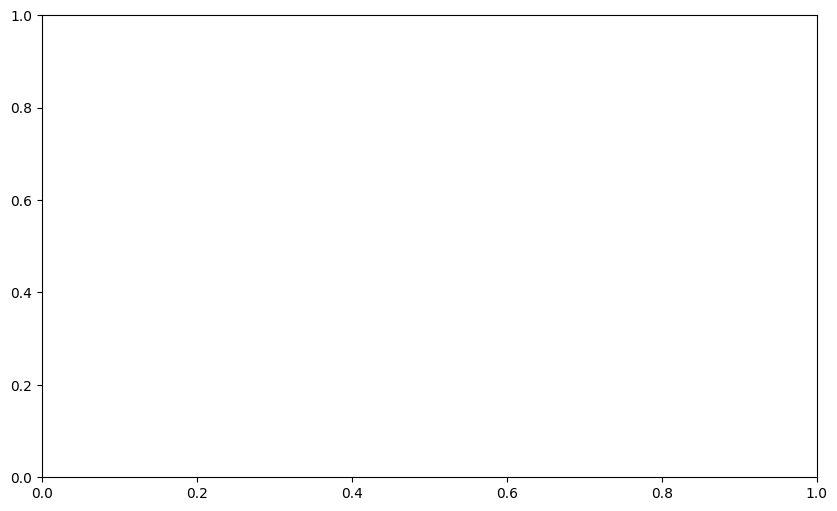

In [30]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df["decimalday"], df["x"] - df["x"][0], label="Latitude")
# ax.set_xlim(340,350)
ax.set

In [12]:
# Combine all start times into one text file
text_files = [
    f"./EventStartTime{min_stas}stas/{year[0]}EventStartTime{min_stas}stas.txt"
    for year in year_arr
]
outfile = f"AllEventStartTimes{min_stas}stas.txt"

# Read in all text files and remove 1st line
with open(outfile, "w") as out_file:
    out_file.write("EventStartTime\n")
    for file in text_files:
        with open(file, "r") as in_file:
            in_file.readline()
            for line in in_file:
                out_file.write(line)

# Combine all no data files into one text file
text_files = [
    f"NoData{min_stas}stas/{year[0]}-{year[0]}no_data_{min_stas}sta.txt"
    for year in year_arr
]
outfile = f"no_data_{min_stas}stas.txt"

# Read in all text files and remove 1st line
with open(outfile, "w") as out_file:
    out_file.write("start\tend\n")
    for file in text_files:
        with open(file, "r") as in_file:
            in_file.readline()
            for line in in_file:
                out_file.write(line)

FileNotFoundError: [Errno 2] No such file or directory: './EventStartTime2stas/2008EventStartTime2stas.txt'